# Verification Notebook 5
# Multi-Model Switching with Contact

In [1]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))
# plot_setup.py lives next to this notebook, which is not the working directory
# when the notebook is executed headlessly (nbmake, papermill).
sys.path.insert(0, str(_repo / "notebooks"))

In [2]:
import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display
from plot_setup import set_professional_style, FULL_WIDTH
plt = set_professional_style(latex=True)

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from syssimx import FMUComponent, System, Connection, EventConnection


## Discover FMUs

In [3]:
PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Modelica Reference Simulation

In [4]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.Contact.RigidContact")
reference.setParameters({'useReset':'true'})
reference.buildModel()
reference.simulate()
ref_sol_names = ('time', 'theta', 'theta_ref', 'theta_meas', 'u_control', 'pid.I_out', 'pendulum.contact')
ref_sol_reset = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


## Instantiate FMU Components

In [5]:
def print_parameteres(component: FMUComponent):
    print(f"Parameters of {component.name}:")
    for name, param in component.parameters.items():
        if '.' not in name and param is not None:
            print(f"  - {name}: {param}")

## Time-Gated Region Key

The region key is `abs(theta)` and the wall sits at `theta = 0`, so the pendulum starts *inside* the
FEM region. Initialization therefore reconciles to FEM and the expensive deformable model runs
through the launch, where the pendulum is accelerating **away** from the wall and cannot contact
anything. That first FEM window lasted about 23 ms, and it buys no fidelity.

`TimeGatedRegionKey` adds a decaying offset to the key so the launch window is spent in the cheap
model. The offset starts at `GATE_OFFSET_RAD`, which is above the outermost boundary's upper
threshold, and ramps linearly to zero at `GATE_T_OPEN_S`. After that the key *is* `abs(theta)` and
the ordinary angle policy governs unchanged.

> **The gate reads the sub-model's clock, not the wrapper's.** `HybridAlgorithm` evaluates region
> indicators by calling `_do_step_internal` directly - in `_detect_crossings` for the trial step and
> in `_evaluate_component_indicators` for every bisection iteration - and only `do_step` advances a
> component's `t`. The wrapper's own `self.t` therefore stays pinned at the left edge of the macro
> step, so a gate reading `comp.t` would return the same value at both ends of the bracket, no sign
> change would be detected, and the gate would never fire. `MultiComponent._do_step_internal`
> delegates to `active_comp.do_step()`, so the active model's clock *is* advanced correctly and is
> the value to read.

> **Why the offset ramps instead of stepping.** A step gate makes the key jump discontinuously when
> it opens. This region map has two boundaries, and one jump can cross both at the same instant;
> `MultiComponent._resolve_region_target` then raises *"Expected one chronological region boundary"*.
> The ramp is continuous, so the key can only reach one boundary at a time.

The gate is not free of consequences. The key now *decreases* through the launch as the offset
decays faster than `abs(theta)` grows, so it crosses the outer boundary downward and produces a
gate-induced `FMU -> OpenSim` transition at about 10 ms. That is a switch with no physical trigger,
and it is the price of removing the FEM launch window. Measured on this system the sequence changes
from `FEM(0 - 0.023) -> OpenSim -> FMU` to `FMU(0 - 0.010) -> OpenSim -> FMU`: the FEM model no
longer runs before the pendulum turns back toward the wall.

In [6]:
# The launch window only has to last until abs(theta) has left the FEM region
# on its own, which happens at about 23 ms. 30 ms covers it with margin. A
# longer gate would also work here, but it would encode this trajectory's
# schedule into the model-selection policy: after the gate expires, proximity
# to the wall alone decides, so an earlier contact can never be missed.
GATE_T_OPEN_S = 0.03

# Must exceed the outermost boundary's upper threshold so that the gated key
# starts in the cheapest region. MasterPendulumSwitchConfig's default outer
# breakpoint is 15 deg with a 1 deg band, i.e. 0.279 rad.
GATE_OFFSET_RAD = 0.35


class TimeGatedRegionKey:
    """Angle region key with a decaying offset that suppresses the launch window.

    The gate reads the active sub-model's clock. `HybridAlgorithm` calls
    `_do_step_internal` directly for trial steps and bisection, which never
    advances the wrapper's own `t`, so a gate on `comp.t` would be constant
    across a macro step and its crossing would never be detected.
    """

    def __init__(self, offset, t_open, mode="ramp"):
        self.offset = float(offset)
        self.t_open = float(t_open)
        self.mode = mode

    def value(self, t, abs_theta):
        """Gated key from a time and an absolute angle, both in SI units.

        Exposed separately so the boundary-localization table below can
        reconstruct the key at a located event without re-running the system.
        """
        if self.mode == "step":
            return self.offset if t < self.t_open else abs_theta
        return abs_theta + self.offset * max(0.0, 1.0 - t / self.t_open)

    def __call__(self, comp):
        raw = comp.outputs["theta"].get()
        abs_theta = 0.0 if raw is None else abs(float(getattr(raw, "magnitude", raw)))
        return self.value(float(comp.active_comp.t), abs_theta)


REGION_GATE = TimeGatedRegionKey(offset=GATE_OFFSET_RAD, t_open=GATE_T_OPEN_S)


class GatedMasterPendulum(MasterPendulum):
    """`MasterPendulum` whose region key is gated through the launch window.

    `MasterPendulum.__init__` builds the region map itself with
    `key=self._absolute_theta`, so overriding that hook is enough. Passing
    `switch_config=None` and calling `set_switch_regions` by hand would also
    work, but it would leave `switch_config` unset and the cells below read it.
    """

    @staticmethod
    def _absolute_theta(component):
        return REGION_GATE(component)

## Components

In [7]:
setpoint = FMUComponent(name="Setpoint",
                         fmu_path=fmu_paths['Trajectories']["SetPoint"],
                         group="Reference")

class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths['Controllers']['PIDControllerReset_euler']
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")

    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})

pid = PIDController(name="PID")

drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                     group="Actuator")

sim_params = config.SimulationParameters()
sim_params.tau = 0.001
sim_params.t_end = 0.4
sim_params.with_contact = True
sim_params.use_gravity = True

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'sim_params': sim_params,
    'anim_params': anim_params,
}

pendulum = GatedMasterPendulum(name="MasterPendulum", initial_mode="FMU")
pendulum.record_switch_state = True
pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

def wall_contact_indicator(comp: MasterPendulum) -> float:
    theta = comp.get_outputs()["theta"]
    theta_wall = 0.0
    theta = theta.magnitude if hasattr(theta, "magnitude") else theta
    return float(theta) - theta_wall

pendulum.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)

angle_sensor = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AngleSensor'],
                             group="Sensors")

angle_decoder = FMUComponent(name="Angle Decoder",
                             fmu_path=fmu_paths['Sensors']['AngleDecoder'],
                             group="Signal Processing")


## Connections

In [8]:
c1 = Connection(
    src_comp=setpoint.name,
    src_port=setpoint.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c21 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c22 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c23 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

connections = [c1, c21, c22, c23, c3, c4, c5]
components  = [setpoint, pid, drive, pendulum, angle_decoder, angle_sensor]

system = System(name="Pendulum System with Master Pendulum")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.add_event_connection(event_connection_1)
system.add_event_connection(event_connection_2)

system.initialize(t0=0.0)

In [9]:
system.algorithm.record_internal_steps = False
system.algorithm.event_dedup_tol = 5e-4
system.algorithm.tol_time = 1e-5
system.algorithm.tol_value = 5e-5

## Run Simulation

In [10]:
t = 0.0
dt = sim_params.tau
t_end = sim_params.t_end

# The declared initial_mode is only a request. Initialization reconciles the
# region from the initialized switching signal, and that reconciliation is not
# recorded in sync_events, so the mode that actually starts the run has to be
# read back here. theta0 = 0 sits inside the FEM region, but the time gate adds
# GATE_OFFSET_RAD at t = 0, so the run starts in the outermost region instead.
initial_mode = pendulum.active_mode
print("declared initial mode : FMU")
print(f"reconciled region     : {pendulum.active_region_index} ({initial_mode})")

system.run(t, t_end, dt)


declared initial mode : FMU
reconciled region     : 2 (FMU)


<SimulationResult 'Pendulum System with Master Pendulum' t=[0.0, 0.4] dt=0.001 components=6 algorithm=HybridAlgorithm>

In [11]:
# system_res_file = _repo / "demos/ControlledPendulum/artifacts/results/master_pendulum_system.csv"
# system_res_file.parent.mkdir(parents=True, exist_ok=True)
# system.history.save_csv(filepath=system_res_file)

## Collect Results

In [12]:
history = system.get_history()
fem_hist = pendulum.fem.get_history()
fmu_hist = pendulum.fmu.get_history()
opensim_hist = pendulum.opensim.get_history()

ref_history = history["Setpoint"]
setpoint_time, data = ref_history
theta_ref = data["theta_ref"]

t_fem = fem_hist['theta']['time']
theta_fem = fem_hist['theta']['values']
t_fmu = fmu_hist['theta']['time']
theta_fmu = fmu_hist['theta']['values']
t_opensim = opensim_hist['theta']['time']
theta_opensim = opensim_hist['theta']['values']

t_pid = history["PID"][0]
i_out = history["PID"][1]['I_out']
u_pid = history["PID"][1]['u']

event_history = history['Events']
event_times_dense = event_history[('MasterPendulum', 'wall_hit')]
event_times_float = [dense.t for dense in event_times_dense]

# Reference contact instants are the rising edges of the Modelica contact flag,
# not every second sample of it: the flag stays high for the whole contact
# phase, so a fixed stride silently mislabels the events it pairs up.
contact_flag = np.asarray(ref_sol_reset['pendulum.contact']) > 0
rising_edges = np.flatnonzero(np.diff(contact_flag.astype(int)) == 1) + 1
event_times_ref = ref_sol_reset['time'][rising_edges]
event_times_ref = event_times_ref[event_times_ref <= t_end]

# Pair only what both sides resolved; an unequal count is a physics difference
# and has to be visible rather than raising a shape error here.
n_events_compared = min(len(event_times_float), len(event_times_ref))
diff_event_times = (
    np.asarray(event_times_float[:n_events_compared], dtype=float)
    - np.asarray(event_times_ref[:n_events_compared], dtype=float)
)

print(f"contact events: syssimx {len(event_times_float)}, "
      f"Modelica {len(event_times_ref)}, compared {n_events_compared}")
if len(event_times_float) != len(event_times_ref):
    print("WARNING: the two runs resolved different contact sequences. "
          "The event-time deltas below pair events that may not correspond.")


contact events: syssimx 5, Modelica 5, compared 5


In [13]:
def trajectory_error_metrics(t, y, t_ref, y_ref, *, t_min=None, t_max=None):
    """Compute sampled trajectory errors against an interpolated reference."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    t_ref = np.asarray(t_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)

    mask = np.ones_like(t, dtype=bool)
    if t_min is not None:
        mask &= t >= t_min
    if t_max is not None:
        mask &= t <= t_max

    t_eval = t[mask]
    y_eval = y[mask]
    y_ref_eval = np.interp(t_eval, t_ref, y_ref)

    err = y_eval - y_ref_eval
    duration = t_eval[-1] - t_eval[0]

    return {
        "e_inf": np.max(np.abs(err)),
        "e_2": np.sqrt(np.trapezoid(err**2, t_eval) / duration),
        "e_mean": np.mean(np.abs(err)),
        "n_samples": len(t_eval),
    }


def event_time_metrics(t_events, t_events_ref):
    """Compare event times pairwise."""
    t_events = np.asarray(t_events, dtype=float)
    t_events_ref = np.asarray(t_events_ref, dtype=float)

    n = min(len(t_events), len(t_events_ref))
    delta = t_events[:n] - t_events_ref[:n]

    return {
        "n_syssimx": len(t_events),
        "n_reference": len(t_events_ref),
        "n_compared": n,
        "max_abs_delta": np.max(np.abs(delta)) if n else np.nan,
        "mean_abs_delta": np.mean(np.abs(delta)) if n else np.nan,
        "delta": delta,
    }


# Main switched plant output.
t_master, data_master = history["MasterPendulum"]
theta_master = np.asarray(data_master["theta"], dtype=float)

# Optional diagnostic signal.
t_pid = np.asarray(t_pid, dtype=float)
i_out = np.asarray(i_out, dtype=float)

# Full horizon errors.
theta_metrics_full = trajectory_error_metrics(
    t_master,
    theta_master,
    ref_sol_reset["time"],
    ref_sol_reset["theta"],
)

pid_metrics_full = trajectory_error_metrics(
    t_pid,
    i_out,
    ref_sol_reset["time"],
    ref_sol_reset["pid.I_out"],
)

# Contact-window errors.
# Use a slightly wider interval than the plotted contact window.
contact_window = (0.15, 0.35)

theta_metrics_contact = trajectory_error_metrics(
    t_master,
    theta_master,
    ref_sol_reset["time"],
    ref_sol_reset["theta"],
    t_min=contact_window[0],
    t_max=contact_window[1],
)

pid_metrics_contact = trajectory_error_metrics(
    t_pid,
    i_out,
    ref_sol_reset["time"],
    ref_sol_reset["pid.I_out"],
    t_min=contact_window[0],
    t_max=contact_window[1],
)

u_metrics_full = trajectory_error_metrics(
    t_pid, u_pid, ref_sol_reset["time"], ref_sol_reset["u_control"])
u_metrics_contact = trajectory_error_metrics(
    t_pid, u_pid, ref_sol_reset["time"], ref_sol_reset["u_control"],
    t_min=contact_window[0], t_max=contact_window[1])


event_metrics = event_time_metrics(event_times_float, event_times_ref)

df_metrics = pd.DataFrame(
    [
        {
            "Quantity": r"$\theta$ full horizon",
            **theta_metrics_full,
        },
        {
            "Quantity": r"$\theta$ contact window",
            **theta_metrics_contact,
        },
        {
            "Quantity": r"$I_{\mathrm{out}}$ full horizon",
            **pid_metrics_full,
        },
        {
            "Quantity": r"$I_{\mathrm{out}}$ contact window",
            **pid_metrics_contact,
        },
        {
            "Quantity": r"$u_{\mathrm{control}}$ full horizon",
            **u_metrics_full,
        },
        {
            "Quantity": r"$u_{\mathrm{control}}$ contact window",
            **u_metrics_contact,
        },
    ]
)

df_metrics


,Quantity,e_inf,e_2,e_mean,n_samples
0,$\theta$ full horizon,0.016235,0.003990,0.002882,426
1,$\theta$ contact window,0.016235,0.005367,0.004230,213
2,$I_{\mathrm{out}}$ full horizon,0.112087,0.007753,0.002624,424
3,$I_{\mathrm{out}}$ contact window,0.112087,0.010931,0.004192,217
4,$u_{\mathrm{control}}$ full horizon,0.139918,0.028237,0.013422,424
5,$u_{\mathrm{control}}$ contact window,0.139918,0.034564,0.013547,217


In [14]:
df_metrics_clean = pd.DataFrame(
    [
        {
            "Signal": "theta",
            "Interval": "full horizon",
            "E_inf": theta_metrics_full["e_inf"],
            "E_2": theta_metrics_full["e_2"],
            "E_mean": theta_metrics_full["e_mean"],
        },
        {
            "Signal": "theta",
            "Interval": "contact window",
            "E_inf": theta_metrics_contact["e_inf"],
            "E_2": theta_metrics_contact["e_2"],
            "E_mean": theta_metrics_contact["e_mean"],
        },
        {
            "Signal": "I_out",
            "Interval": "full horizon",
            "E_inf": pid_metrics_full["e_inf"],
            "E_2": pid_metrics_full["e_2"],
            "E_mean": pid_metrics_full["e_mean"],
        },
        {
            "Signal": "I_out",
            "Interval": "contact window",
            "E_inf": pid_metrics_contact["e_inf"],
            "E_2": pid_metrics_contact["e_2"],
            "E_mean": pid_metrics_contact["e_mean"],
        },
        {
            "Signal": "u_control",
            "Interval": "full horizon",
            "E_inf": u_metrics_full["e_inf"],
            "E_2": u_metrics_full["e_2"],
            "E_mean": u_metrics_full["e_mean"],
        },
        {
            "Signal": "u_control",
            "Interval": "contact window",
            "E_inf": u_metrics_contact["e_inf"],
            "E_2": u_metrics_contact["e_2"],
            "E_mean": u_metrics_contact["e_mean"],
        },
    ]
)

display(
    df_metrics_clean.style
    .format({"E_inf": "{:.3e}", "E_2": "{:.3e}", "E_mean": "{:.3e}"})
    .hide(axis="index")
)


Signal,Interval,E_inf,E_2,E_mean
theta,full horizon,1.623e-02,3.990e-03,2.882e-03
theta,contact window,1.623e-02,5.367e-03,4.230e-03
I_out,full horizon,1.121e-01,7.753e-03,2.624e-03
I_out,contact window,1.121e-01,1.093e-02,4.192e-03
u_control,full horizon,1.399e-01,2.824e-02,1.342e-02
u_control,contact window,1.399e-01,3.456e-02,1.355e-02


In [15]:
df_metrics_latex = df_metrics_clean.copy()
df_metrics_latex = df_metrics_latex.rename(
    columns={
        "E_inf": r"$E_\infty$",
        "E_2": r"$E_2$",
        "E_mean": r"$E_\mathrm{mean}$",
    }
)

print(
    df_metrics_latex.to_latex(
        index=False,
        escape=False,
        float_format="{:.3e}".format,
    )
)


\begin{tabular}{llrrr}
\toprule
Signal & Interval & $E_\infty$ & $E_2$ & $E_\mathrm{mean}$ \\
\midrule
theta & full horizon & 1.623e-02 & 3.990e-03 & 2.882e-03 \\
theta & contact window & 1.623e-02 & 5.367e-03 & 4.230e-03 \\
I_out & full horizon & 1.121e-01 & 7.753e-03 & 2.624e-03 \\
I_out & contact window & 1.121e-01 & 1.093e-02 & 4.192e-03 \\
u_control & full horizon & 1.399e-01 & 2.824e-02 & 1.342e-02 \\
u_control & contact window & 1.399e-01 & 3.456e-02 & 1.355e-02 \\
\bottomrule
\end{tabular}



In [16]:
df_events = pd.DataFrame({
    "syssimx (s)": event_times_float[:n_events_compared],
    "Modelica (s)": event_times_ref[:n_events_compared],
    "Delta (s)": diff_event_times,
})
df_events.index.name = "Event"
df_events.style.format("{:.6f}")


,syssimx (s),Modelica (s),Delta (s)
Event,,,
0,0.172406,0.172112,0.000294
1,0.211669,0.211092,0.000577
2,0.250981,0.250071,0.000910
3,0.290350,0.289050,0.001300
4,0.330113,0.328029,0.002083


In [17]:
print(f"E_inf theta full      = {theta_metrics_full['e_inf']:.3e} rad")
print(f"E_2 theta full        = {theta_metrics_full['e_2']:.3e} rad")
print(f"E_inf theta contact   = {theta_metrics_contact['e_inf']:.3e} rad")
print(f"E_2 theta contact     = {theta_metrics_contact['e_2']:.3e} rad")
print(f"max event time error  = {event_metrics['max_abs_delta']:.3e} s")


E_inf theta full      = 1.623e-02 rad
E_2 theta full        = 3.990e-03 rad
E_inf theta contact   = 1.623e-02 rad
E_2 theta contact     = 5.367e-03 rad
max event time error  = 2.083e-03 s


In [18]:
def build_mode_intervals(sync_events, initial_mode, t0, tf):
    rows = []
    current_mode = initial_mode
    current_t = t0

    for event in sync_events:
        switch_t = event["time"]
        rows.append((current_t, switch_t, current_mode))
        current_t = switch_t
        current_mode = event["to_mode"]

    rows.append((current_t, tf, current_mode))
    return rows

# initial_mode is the reconciled mode read back before the run, not the mode
# requested at construction.
mode_intervals = build_mode_intervals(
    pendulum.sync_events,
    initial_mode=initial_mode,
    t0=0.0,
    tf=t_end,
)


## Plot: Multi-Model Switching
This plot overlays all three sub-models and the setpoint.

In [19]:
marker_size = 2
palette = {
    "fem": "#1f77b4",
    "opensim": "#ff7f0e",
    "fmu": "#2ca02c",
    "setpoint": "#d62728",
}

fem_style = {
    "color": palette["fem"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}
opensim_style = {
    "color": palette["opensim"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}
fmu_style = {
    "color": palette["fmu"],
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 2.5,
}

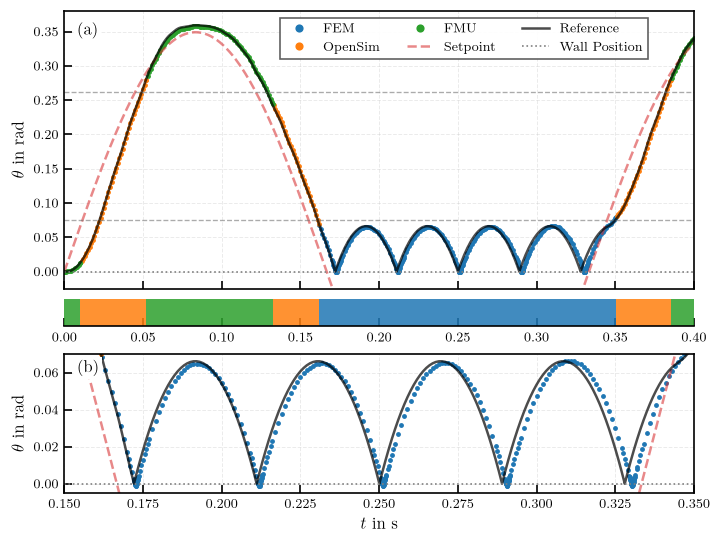

In [20]:
fig = plt.figure(figsize=(FULL_WIDTH, 0.75 * FULL_WIDTH), constrained_layout=True)
gs = fig.add_gridspec(3, 1, height_ratios=[4, 0.4, 2])
ax_full = fig.add_subplot(gs[0, 0])
ax_mode = fig.add_subplot(gs[1, 0], sharex=ax_full)
ax_contact = fig.add_subplot(gs[2, 0])

for ax in (ax_full, ax_contact):
    ax.plot(t_fem, theta_fem, label="FEM", **fem_style)
    ax.plot(t_opensim, theta_opensim, label="OpenSim", **opensim_style)
    ax.plot(t_fmu, theta_fmu, label="FMU", **fmu_style)
    ax.plot(setpoint_time, theta_ref, label="Setpoint", color=palette["setpoint"], linestyle="--", linewidth=1.5, alpha=0.55)
    ax.plot(ref_sol_reset['time'], ref_sol_reset['theta'], 'k-', label="Reference", markersize=1, linewidth=1.5, alpha=0.7)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1, label="Wall Position")
    for threshold in pendulum.switch_regions.breakpoints:
        ax.axhline(threshold, color="0.45", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")

ax_full.set_ylim(-0.025, 0.38)
ax_full.tick_params(labelbottom=False)
ax_full.legend(loc="upper center", bbox_to_anchor=(0.635, 1), ncol=3, markerscale=2, fontsize=8)
ax_contact.set_xlabel(r"$t$ in $\mathrm{s}$")

ax_contact.set_xlim(0.15, 0.35)
ax_contact.set_ylim(-0.005, 0.07)

for t0_i, t1_i, mode in mode_intervals:
    ax_mode.broken_barh(
        [(t0_i, t1_i - t0_i)],
        (0, 1),
        facecolors=palette[mode.lower()],
        edgecolors="none",
        alpha=0.85,
    )

ax_mode.set_ylim(0, 1)
ax_mode.set_xlim(0, t_end)
ax_mode.set_yticks([])
ax_mode.grid(False)

for spine in ["left", "right", "top"]:
    ax_mode.spines[spine].set_visible(False)

for label, ax in [("(a)", ax_full), ("(b)", ax_contact)]:
    ax.text(0.02, 0.96,
        label, transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=1.5),
    )

out = _repo / "notebooks" / "figures"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "05_a_multi_model_switching.pdf")
plt.show()


### Model Switching and Synchronicity

Each committed transfer carries a `PendulumTransferReport`. Two groups of quantities have to be read
differently.

`theta`, `omega`, and `tau` are *enforced* invariants. `MasterPendulum._build_transfer_report`
raises and rolls the transaction back when any of them jumps further than the configured tolerance,
so a completed run cannot show a violation of them. Their columns below confirm the transaction
contract held; they are not a measurement of switching quality.

`alpha` and the energy terms are *measured but not enforced*, because the canonical interface
carries angular position, velocity, and torque only. They are the quantities that actually price a
handover. `elastic_lost` is the strain energy present in the FEM state and absent from the rigid
target, which is the projection loss of leaving the deformable model.


In [21]:
switch_rows = []
for event in pendulum.sync_events:
    report = event["transfer_report"]
    semantics = report.semantics
    switch_rows.append({
        "t": event["time"],
        "from": event["from_mode"],
        "to": event["to_mode"],
        # Enforced by the transaction: these cannot exceed the tolerances.
        "d_theta": report.theta_error,
        "d_omega": report.omega_error,
        "d_tau": report.tau_error,
        # Measured only: the real cost of the handover.
        "d_alpha": report.alpha_error,
        "d_energy": report.energy_error,
        "elastic_lost": report.elastic_energy_lost,
        "d_energy_total": report.total_energy_error,
        "lost_canonical": ", ".join(
            name for name in semantics.lost if name in ("theta", "omega", "alpha", "tau")
        ) or "-",
        "violations": ", ".join(report.violations(pendulum.transfer_tolerances)) or "-",
    })

df_switching = pd.DataFrame(switch_rows)

display(
    df_switching.style
    .format({
        "t": "{:.6f}",
        "d_theta": "{:.3e}",
        "d_omega": "{:.3e}",
        "d_tau": "{:.3e}",
        "d_alpha": "{:.3e}",
        "d_energy": "{:.3e}",
        "elastic_lost": "{:.3e}",
        "d_energy_total": "{:.3e}",
    })
    .hide(axis="index")
)


t,from,to,d_theta,d_omega,d_tau,d_alpha,d_energy,elastic_lost,d_energy_total,lost_canonical,violations
0.010164,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,1.137e-13,0.000e+00,0.000e+00,0.000e+00,alpha,-
0.052055,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,5.684e-14,0.000e+00,0.000e+00,0.000e+00,alpha,-
0.132539,FMU,OpenSim,0.000e+00,0.000e+00,0.000e+00,5.684e-14,0.000e+00,0.000e+00,0.000e+00,alpha,-
0.161711,OpenSim,FEM,9.714e-17,9.770e-15,1.776e-15,0.000e+00,3.109e-15,-6.612e-19,3.109e-15,alpha,-
0.350797,FEM,OpenSim,0.000e+00,0.000e+00,0.000e+00,3.981e-05,0.000e+00,5.972e-07,5.972e-07,alpha,-
0.385297,OpenSim,FMU,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,0.000e+00,alpha,-


In [22]:
switch_summary = {
    "n_switches": len(df_switching),
    "tol_theta": pendulum.transfer_tolerances.theta,
    "tol_omega": pendulum.transfer_tolerances.omega,
    "tol_tau": pendulum.transfer_tolerances.tau,
    "max_d_theta": df_switching["d_theta"].max(),
    "max_d_omega": df_switching["d_omega"].max(),
    "max_d_tau": df_switching["d_tau"].max(),
    "max_d_alpha": df_switching["d_alpha"].max(),
    "max_d_energy": df_switching["d_energy"].max(),
    "max_elastic_lost": df_switching["elastic_lost"].max(),
    "any_violation": bool((df_switching["violations"] != "-").any()),
}

switch_summary


{'n_switches': 6,
 'tol_theta': 1e-08,
 'tol_omega': 1e-08,
 'tol_tau': 1e-10,
 'max_d_theta': np.float64(9.71445146547012e-17),
 'max_d_omega': np.float64(9.769962616701378e-15),
 'max_d_tau': np.float64(1.7763568394002505e-15),
 'max_d_alpha': np.float64(3.980790393143252e-05),
 'max_d_energy': np.float64(3.1086244689504383e-15),
 'max_elastic_lost': np.float64(5.971871711093401e-07),
 'any_violation': False}

### Boundary Localization

The key is the **gated** signal defined above, `abs(theta)` plus a decaying launch offset, so a
crossing located before `GATE_T_OPEN_S` sits at a different angle than its breakpoint suggests.

`set_switch_regions()` generates one bidirectional indicator per physical boundary, named
`region_boundary_i`, and the hybrid algorithm localizes each crossing by bisection. Those events are
recorded in the system event history alongside `wall_hit`, so the placement of every region change
can be read directly rather than inferred from the switch log.

Each boundary is a Schmitt trigger: the indicator is armed at the far edge of its hysteresis band,
so a located crossing sits on `breakpoint + band` when the key rises and on `breakpoint - band` when
it falls, never on the breakpoint itself. `armed` is that active threshold and `residual` is the
distance of the key from it at the located instant, which shows how tightly the crossing was
resolved. Measuring against the nominal breakpoint instead would report the band width and say
nothing about localization.

`off_grid` is the distance from the located instant to the nearest communication point. It shows
that the transition is placed independently of the macro grid: a value near zero would mean the
switch merely landed on a step boundary.


In [23]:
t_master, data_master = history["MasterPendulum"]
t_master = np.asarray(t_master, dtype=float)
abs_theta_master = np.abs(np.asarray(data_master["theta"], dtype=float))

boundaries = pendulum.switch_regions.boundaries


def _distance_to_grid(t_value, step):
    """Distance from t_value to the nearest communication point."""
    remainder = t_value % step
    return min(remainder, step - remainder)


boundary_rows = []
for (comp_name, event_name), records in event_history.items():
    if not event_name.startswith("region_boundary_"):
        continue
    boundary = boundaries[int(event_name.rsplit("_", 1)[1])]
    for record in records:
        t_event = float(record.t)
        # The located instant is an accepted communication point of the run, so
        # interpolating the recorded trajectory reproduces the key there.
        # The key is the gated signal, not abs(theta): before GATE_T_OPEN_S the
        # two differ by the decaying offset, and the armed threshold is compared
        # against the key the algorithm actually saw.
        key_value = REGION_GATE.value(
            t_event, float(np.interp(t_event, t_master, abs_theta_master))
        )
        # Which band edge was armed follows from the side the key ended up on.
        armed = (
            boundary.upper_threshold
            if key_value >= boundary.breakpoint
            else boundary.lower_threshold
        )
        committed = [e for e in pendulum.sync_events if abs(e["time"] - t_event) <= 1e-12]
        boundary_rows.append({
            "t": t_event,
            "boundary": event_name,
            "breakpoint": boundary.breakpoint,
            "band": boundary.band,
            "armed": armed,
            "key": key_value,
            "residual": key_value - armed,
            "off_grid": _distance_to_grid(t_event, dt),
            "switch": f"{committed[0]['from_mode']} -> {committed[0]['to_mode']}" if committed else "-",
        })

df_boundaries = pd.DataFrame(boundary_rows).sort_values("t").reset_index(drop=True)

if df_boundaries.empty:
    print("No region boundary crossings were localized in this run.")
else:
    display(
        df_boundaries.style
        .format({
            "t": "{:.6f}",
            "breakpoint": "{:.4f}",
            "band": "{:.4f}",
            "armed": "{:.6f}",
            "key": "{:.6f}",
            "residual": "{:.3e}",
            "off_grid": "{:.3e}",
        })
        .hide(axis="index")
    )
    print(f"macro step dt        = {dt:.3e} s")
    print(f"max |residual|       = {df_boundaries['residual'].abs().max():.3e} rad")
    print(f"min off-grid offset  = {df_boundaries['off_grid'].min():.3e} s")
    print(f"tol_time             = {system.algorithm.tol_time:.3e} s")
    print(f"tol_value            = {system.algorithm.tol_value:.3e} rad")


t,boundary,breakpoint,band,armed,key,residual,off_grid,switch
0.010164,region_boundary_1,0.2618,0.0175,0.244346,0.244291,-5.472e-05,1.641e-04,FMU -> OpenSim
0.052055,region_boundary_1,0.2618,0.0175,0.279253,0.279279,2.615e-05,5.469e-05,OpenSim -> FMU
0.132539,region_boundary_1,0.2618,0.0175,0.244346,0.244366,1.974e-05,4.609e-04,FMU -> OpenSim
0.161711,region_boundary_0,0.0750,0.0050,0.070000,0.070052,5.163e-05,2.891e-04,OpenSim -> FEM
0.350797,region_boundary_0,0.0750,0.0050,0.080000,0.080036,3.620e-05,2.031e-04,FEM -> OpenSim
0.385297,region_boundary_1,0.2618,0.0175,0.279253,0.279252,-3.034e-07,2.969e-04,OpenSim -> FMU


macro step dt        = 1.000e-03 s
max |residual|       = 5.472e-05 rad
min off-grid offset  = 5.469e-05 s
tol_time             = 1.000e-05 s
tol_value            = 5.000e-05 rad


## PID Controller Trajectory

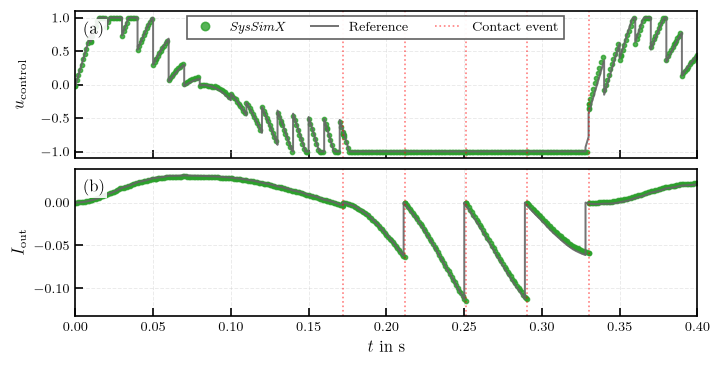

In [24]:
fig, (ax_u, ax_i) = plt.subplots(
    2, 1, sharex=True,
    figsize=(FULL_WIDTH, 0.5 * FULL_WIDTH),
    constrained_layout=True,
)

ref_style = dict(linestyle="-", color="0.4", linewidth=1.2, alpha=0.9)
cs_style  = dict(linestyle="None", marker="o", markersize=2.5, alpha=0.8,
                 color=palette["fmu"])

# (a) controller output command
ax_u.plot(t_pid, u_pid, **cs_style, label=r"\textit{SysSimX}")
ax_u.plot(ref_sol_reset["time"], ref_sol_reset["u_control"], **ref_style, label="Reference")


# (b) integrator state
ax_i.plot(t_pid, i_out, **cs_style)
ax_i.plot(ref_sol_reset["time"], ref_sol_reset["pid.I_out"], **ref_style)


# contact events on both panels, labelled once
for ax in (ax_u, ax_i):
    for k, t_event in enumerate(event_times_float):
        ax.axvline(
            t_event, color="red", linestyle=":", linewidth=1, alpha=0.5,
            label="Contact event" if (ax is ax_u and k == 0) else None,
        )

for ax in (ax_u, ax_i):
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_end)

ax_u.set_ylabel(r"$u_{\mathrm{control}}$")
ax_i.set_ylabel(r"$I_{\mathrm{out}}$")
ax_i.set_xlabel(r"$t$ in $\mathrm{s}$")

for label, ax in [("(a)", ax_u), ("(b)", ax_i)]:
    ax.text(
        0.012, 0.93, label, transform=ax.transAxes,
        ha="left", va="top", fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5),
    )

fig.align_ylabels((ax_u, ax_i))

handles, labels = ax_u.get_legend_handles_labels()
fig.legend(handles, labels, ncol=3,
           fontsize=8, markerscale=2, frameon=True, loc="upper center", bbox_to_anchor=(0.52, 0.99))

out = _repo / "notebooks" / "figures"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "05_b_multi_model_controller.pdf")
plt.show()
